# ¡Hola Edgar! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Buen trabajo Edgar! Has completado correctamente todo lo necesario del notebook, realizaste un gran trabajo aplicando los conocimientos de analítica necesarios, se nota que los manejas muy bien. No tengo comentarios de corrección, tu proyecto está aprobado. Felicitaciones por completar el notebook en la primera revisión, mucho éxito en el siguiente sprint!

Saludos!

</div>

----

In [3]:
#Librerias
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import math
from scipy.stats import shapiro
from scipy.stats import ttest_ind
import seaborn as sns

In [4]:
company = pd.read_csv('/datasets/project_sql_result_01.csv')
location = pd.read_csv('/datasets/project_sql_result_04.csv')
loop_to_airport = pd.read_csv('/datasets/project_sql_result_07.csv')

In [5]:
print(company.head())
print(location.head())
print(loop_to_airport.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


In [6]:
company.info()
location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


Los datos parecen estar en el formato adecuado, y no contienen nulos, al igual que los titulos no necesitan correcciones.

In [7]:
ordered_company=company.sort_values('trips_amount',ascending=False).head(10)
print(ordered_company)

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


In [8]:
ordered_location=location.sort_values('average_trips',ascending=False).head(10)
print(ordered_location)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>


Muy bien hecho con la revisión inicial de la data, ahora tenemos los tipos correctos y sabemos con claridad lo que contiene 



</div>

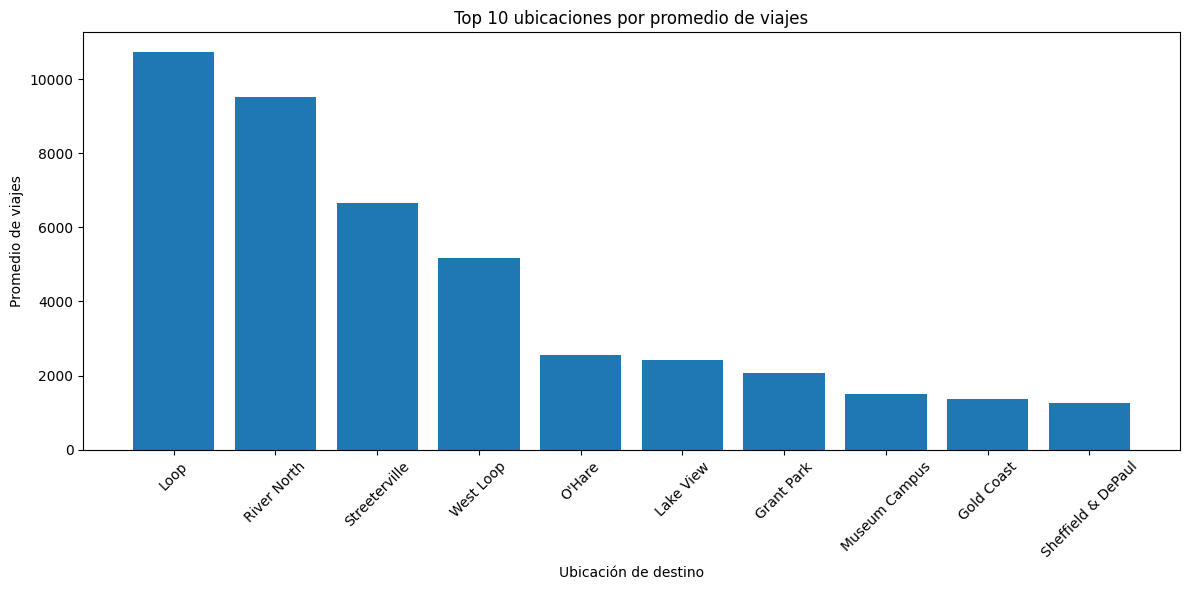

In [9]:

plt.figure(figsize=(12, 6))  
plt.bar(ordered_location['dropoff_location_name'], ordered_location['average_trips'])
plt.xticks(rotation=45)
plt.xlabel('Ubicación de destino')
plt.ylabel('Promedio de viajes')
plt.title('Top 10 ubicaciones por promedio de viajes')  
plt.tight_layout()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

¡Buen trabajo obteniendo el top de barrios! El gráfico está ordenado de mayor a menor, lo que permite notar correctamente que Loop Y River North son los principales destinos. Tal vez tienen atractivos importantes que los hacen lugares de muchas visitas.

</div>

Podemos observar que el top 3 de destinos son altamente superiores a los demas, si hay algun tipo de informacion que queremos que el cliente vea seria de suma importancia enfocarse en estos tres destinos o de igual manera nos da a entender el flujo de personas que hay en esas areas.

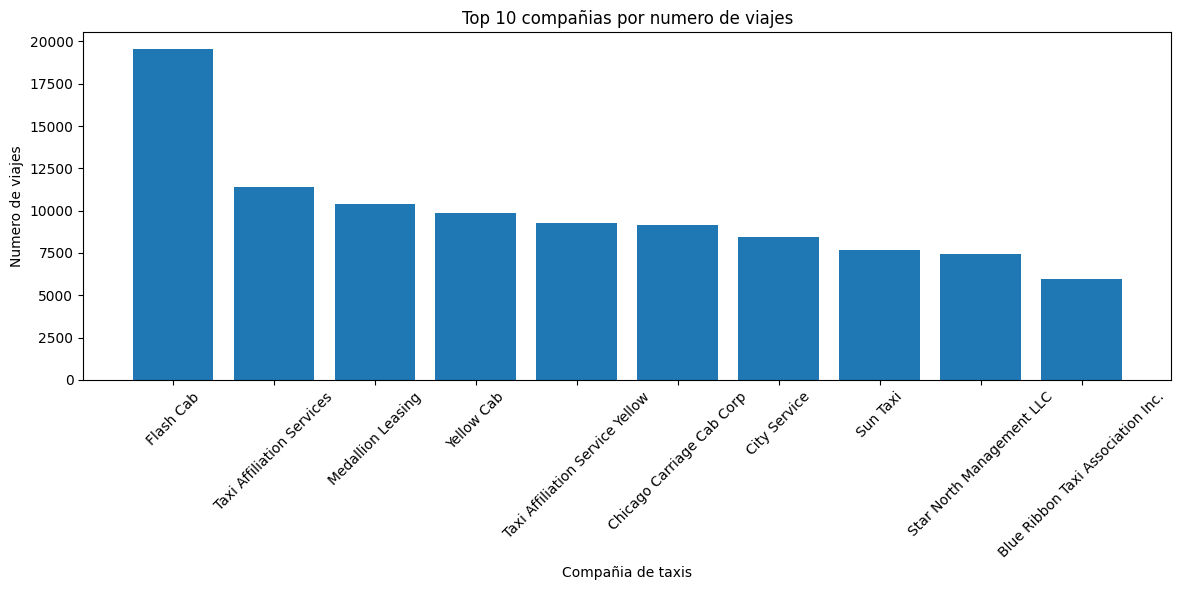

In [10]:
plt.figure(figsize=(12, 6))  
plt.bar(ordered_company['company_name'], ordered_company['trips_amount'])
plt.xticks(rotation=45)
plt.xlabel('Compañia de taxis')
plt.ylabel('Numero de viajes')
plt.title('Top 10 compañias por numero de viajes')  
plt.tight_layout()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

¡Muy buen trabajo con la gráfica! Observamos que Flash Cab tiene el liderazgo de cantidad de viajes, bastante más arriba que el competidor que le sigue. Esta concentración de mercado se puede dar por varios factores como cobertura, cantidad de vehículos o buenas estrategias comerciales.

</div>

A diferencia de los destinos no hay tanta variabilidad en el top 1o de compañias excluyendo el primer lugar que practicamente duplica a todas sus competencias. Si Flash Cab exigiera cerca del doble que las demas compañias por correr publicidad en sus taxis seria una decision correcta el tomarlo por el flujo de viajes que tiene.

In [11]:
#cambio de formato en la columba start_ts a datetime 
loop_to_airport['start_ts']=pd.to_datetime(loop_to_airport['start_ts'])
loop_to_airport.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


In [12]:
loop_to_airport['day_of_week'] = loop_to_airport['start_ts'].dt.dayofweek


In [13]:

bad_weather=loop_to_airport[loop_to_airport['weather_conditions']=='Bad'].reset_index(drop=True)
print(bad_weather)


               start_ts weather_conditions  duration_seconds  day_of_week
0   2017-11-04 16:00:00                Bad            2969.0            5
1   2017-11-18 12:00:00                Bad            1980.0            5
2   2017-11-04 17:00:00                Bad            2460.0            5
3   2017-11-04 16:00:00                Bad            2760.0            5
4   2017-11-18 12:00:00                Bad            2460.0            5
..                  ...                ...               ...          ...
175 2017-11-18 12:00:00                Bad            2560.0            5
176 2017-11-18 10:00:00                Bad            1908.0            5
177 2017-11-18 12:00:00                Bad            2400.0            5
178 2017-11-18 16:00:00                Bad            2186.0            5
179 2017-11-04 16:00:00                Bad            2834.0            5

[180 rows x 4 columns]


In [14]:
good_weather=loop_to_airport[loop_to_airport['weather_conditions']=='Good'].reset_index(drop=True)
print(good_weather)


               start_ts weather_conditions  duration_seconds  day_of_week
0   2017-11-25 16:00:00               Good            2410.0            5
1   2017-11-25 14:00:00               Good            1920.0            5
2   2017-11-25 12:00:00               Good            1543.0            5
3   2017-11-04 10:00:00               Good            2512.0            5
4   2017-11-11 07:00:00               Good            1440.0            5
..                  ...                ...               ...          ...
883 2017-11-11 06:00:00               Good            1500.0            5
884 2017-11-25 11:00:00               Good               0.0            5
885 2017-11-11 10:00:00               Good            1318.0            5
886 2017-11-11 13:00:00               Good            2100.0            5
887 2017-11-11 08:00:00               Good            1380.0            5

[888 rows x 4 columns]


Prueba de hipotesis:
Hipotesis nula: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare NO cambia los sábados lluviosos.
Hipotesis alterna: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos.

In [20]:
good_weather_seconds = good_weather['duration_seconds']
bad_weather_seconds = bad_weather['duration_seconds']
print("H₀ = La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare NO cambia los sábados lluviosos.")
print("H₁ = La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos.")
print('alpha = .05')
statistic, p_value = ttest_ind(good_weather_seconds, bad_weather_seconds)
print()
print('p value es ', p_value)
if p_value < .05:
    print('Rechazamos la hipotesis nula, los promedios son diferentes')
else:
    print('No rechazamos la hipotesis nula, los promedios no son diferentes')

H₀ = La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare NO cambia los sábados lluviosos.
H₁ = La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos.
alpha = .05

p value es  6.517970327099473e-12
Rechazamos la hipotesis nula, los promedios son diferentes


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el test de hipótesis, fue realizado de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales. Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es estadísticamente diferente. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).





</div>

Analizando los resultados podemos observar que el clima si afecta a los viajes en la aplicacion.